<a href="https://colab.research.google.com/github/evolymwillyaa-commits/glaucoma-detection/blob/main/notebooks/model_glaukoma_Mahitala_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# Load the labels file
labels_df = pd.read_csv("Labels.csv")
print("Total images:", len(labels_df))
labels_df.head()
# Count glaucoma vs non-glaucoma images
print("Class distribution:")
print(labels_df['Label'].value_counts())

Total images: 747
Class distribution:
Label
GON+    548
GON-    199
Name: count, dtype: int64


Quality score stats: {'count': 747.0, 'mean': 5.9043105756358765, 'std': 1.007188851857602, 'min': 2.04, '25%': 5.365, '50%': 6.18, '75%': 6.63, 'max': 7.69}


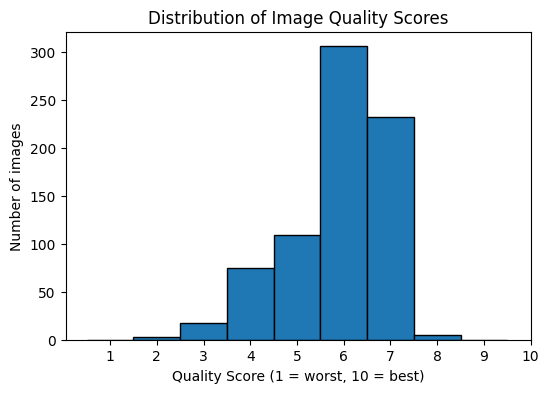

In [ ]:
# Basic statistics of quality scores
quality_stats = labels_df['Quality Score'].describe()
print("Quality score stats:", quality_stats.to_dict())
# Plot a histogram of quality scores
plt.figure(figsize=(6,4))
plt.hist(labels_df['Quality Score'], bins=np.arange(1, 11) - 0.5,
edgecolor='black')
plt.xticks(range(1, 11))
plt.title("Distribution of Image Quality Scores")
plt.xlabel("Quality Score (1 = worst, 10 = best)")
plt.ylabel("Number of images")
plt.show()

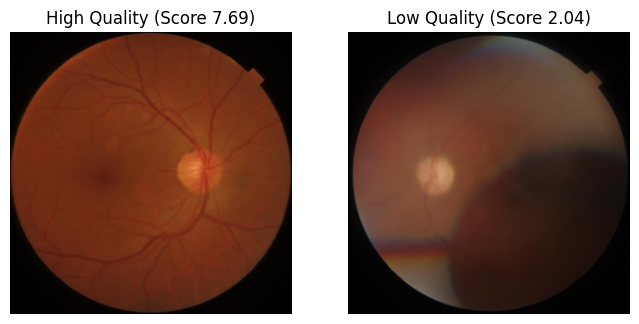

In [ ]:
from PIL import Image
import os
import matplotlib.pyplot as plt

highest_quality_row = labels_df.loc[labels_df['Quality Score'].idxmax()]
lowest_quality_row  = labels_df.loc[labels_df['Quality Score'].idxmin()]

high_img_path = str(highest_quality_row['Image Name'])  # <-- tanpa "Images"
low_img_path  = str(lowest_quality_row['Image Name'])

high_img = Image.open(high_img_path)
low_img  = Image.open(low_img_path)

display_size = (300, 300)
high_img_resized = high_img.resize(display_size)
low_img_resized  = low_img.resize(display_size)

fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(high_img_resized)
axs[0].set_title(f"High Quality (Score {highest_quality_row['Quality Score']})")
axs[0].axis('off')
axs[1].imshow(low_img_resized)
axs[1].set_title(f"Low Quality (Score {lowest_quality_row['Quality Score']})")
axs[1].axis('off')
plt.show()

In [ ]:
import numpy as np

# Ensure reproducibility
np.random.seed(42)

# Get unique patients and their labels (ambil 1 label per patient)
patient_groups = labels_df.groupby('Patient')['Label'].first()
patients = patient_groups.index.tolist()         # list patient ID
patient_labels = patient_groups.values.tolist()  # list label per patient

# Separate patients by glaucoma status
glauc_patients  = [p for p, lab in zip(patients, patient_labels) if lab == 'GON+']
normal_patients = [p for p, lab in zip(patients, patient_labels) if lab == 'GON-']

# Shuffle
np.random.shuffle(glauc_patients)
np.random.shuffle(normal_patients)

# Define split sizes
train_frac = 0.80
val_frac   = 0.10  # test otomatis sisa 0.10

def split_patient_list(patient_list, train_frac, val_frac):
    n = len(patient_list)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))
    train_list = patient_list[:train_end]
    val_list   = patient_list[train_end:val_end]
    test_list  = patient_list[val_end:]
    return train_list, val_list, test_list

# Split glaucoma and normal patient lists
glauc_train, glauc_val, glauc_test = split_patient_list(glauc_patients, train_frac, val_frac)
norm_train,  norm_val,  norm_test  = split_patient_list(normal_patients, train_frac, val_frac)

# Combine to form final patient splits
train_patients = set(glauc_train + norm_train)
val_patients   = set(glauc_val + norm_val)
test_patients  = set(glauc_test + norm_test)

print(f"Patients split: {len(train_patients)} train, {len(val_patients)} val, {len(test_patients)} test.")

# Double-check no overlap
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

Patients split: 229 train, 29 val, 30 test.


In [ ]:
train_df = labels_df[labels_df['Patient'].isin(train_patients)].copy()
val_df = labels_df[labels_df['Patient'].isin(val_patients)].copy()
6
test_df = labels_df[labels_df['Patient'].isin(test_patients)].copy()
print("Train set: total images =", len(train_df), " | glaucoma =",
sum(train_df['Label']=='GON+'), "| normal =", sum(train_df['Label']=='GON-'))
print("Val set: total images =", len(val_df), " | glaucoma =",
sum(val_df['Label']=='GON+'), "| normal =", sum(val_df['Label']=='GON-'))
print("Test set: total images =", len(test_df), " | glaucoma =",
sum(test_df['Label']=='GON+'), "| normal =", sum(test_df['Label']=='GON-'))

Train set: total images = 595  | glaucoma = 434 | normal = 161
Val set: total images = 83  | glaucoma = 64 | normal = 19
Test set: total images = 69  | glaucoma = 50 | normal = 19


In [ ]:
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 224  # target size for model input

# Preprocessing function: load image from disk, resize, ensure 3 channels, apply ResNet50 preprocess
def load_and_preprocess_image(image_path):
    # Read the image from file
    img = Image.open(image_path).convert("RGB")  # convert memastikan 3 channel
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32)

    # ResNet50 preprocessing (BGR + mean subtraction inside preprocess_input)
    img_pre = preprocess_input(img)
    return img_pre

# Keras augmentation layers (opsional, untuk training)
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),          # ~10% dari 360 derajat
    tf.keras.layers.RandomBrightness(0.2),        # butuh TF versi yang support layer ini
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation")

In [ ]:
import os
import numpy as np
import tensorflow as tf

# ========= 0) SET FOLDER GAMBAR =========
# Kalau gambar kamu ada langsung di panel Files (root), pakai "."
# Kalau memang ada folder "Images", pakai "Images"
IMAGES_DIR = "."   # <-- ganti ke "Images" kalau kamu benar2 punya folder Images

# ========= 1) LABEL KE INT =========
label_to_int = {'GON-': 0, 'GON+': 1}

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df['LabelInt'] = train_df['Label'].map(label_to_int)
val_df['LabelInt']   = val_df['Label'].map(label_to_int)
test_df['LabelInt']  = test_df['Label'].map(label_to_int)

# ========= 2) LOAD TRAIN =========
X_train_img = []
X_train_quality = []
y_train = []

for _, row in train_df.iterrows():
    img_path = os.path.join(IMAGES_DIR, str(row['Image Name']))
    img_pre = load_and_preprocess_image(img_path)

    X_train_img.append(img_pre)
    X_train_quality.append(float(row['Quality Score']) / 10.0)  # normalize to [0,1]
    y_train.append(int(row['LabelInt']))

X_train_img = np.array(X_train_img)
X_train_quality = np.array(X_train_quality).reshape(-1, 1)
y_train = np.array(y_train)

print("Loaded training images:", X_train_img.shape, "Quality shape:", X_train_quality.shape)

# ========= 3) AUGMENT TRAIN =========
augmented_imgs = []
augmented_quality = []
augmented_labels = []

for i in range(len(X_train_img)):
    img = X_train_img[i]

    # augmentation expects batch dim
    img_batch = tf.expand_dims(img, axis=0)                 # (1, H, W, C)
    aug_img_batch = augmentation(img_batch, training=True)  # (1, H, W, C)
    aug_img = aug_img_batch.numpy()[0]

    augmented_imgs.append(aug_img)
    augmented_quality.append(X_train_quality[i])  # quality stays same
    augmented_labels.append(y_train[i])

# Combine original + augmented
X_train_img = np.concatenate([X_train_img, np.array(augmented_imgs)], axis=0)
X_train_quality = np.concatenate([X_train_quality, np.array(augmented_quality)], axis=0)
y_train = np.concatenate([y_train, np.array(augmented_labels)], axis=0)

print("Training set size after augmentation:", X_train_img.shape[0])

# Shuffle after augmentation
perm = np.random.permutation(len(y_train))
X_train_img = X_train_img[perm]
X_train_quality = X_train_quality[perm]
y_train = y_train[perm]

# ========= 4) PREPARE VAL/TEST (NO AUGMENT) =========
def prepare_dataset(df):
    X_img = []
    X_quality = []
    y = []

    for _, row in df.iterrows():
        img_path = os.path.join(IMAGES_DIR, str(row['Image Name']))
        img_pre = load_and_preprocess_image(img_path)

        X_img.append(img_pre)
        X_quality.append(float(row['Quality Score']) / 10.0)
        y.append(int(row['LabelInt']))

    return np.array(X_img), np.array(X_quality).reshape(-1, 1), np.array(y)

X_val_img, X_val_quality, y_val = prepare_dataset(val_df)
X_test_img, X_test_quality, y_test = prepare_dataset(test_df)

print("Validation set:", X_val_img.shape, X_val_quality.shape, "Test set:", X_test_img.shape, X_test_quality.shape)

Loaded training images: (595, 224, 224, 3) Quality shape: (595, 1)
Training set size after augmentation: 1190
Validation set: (83, 224, 224, 3) (83, 1) Test set: (69, 224, 224, 3) (69, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the two inputs
image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
quality_input = layers.Input(shape=(1,), name="quality_input")

# Image branch: Pre-trained ResNet50
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=image_input
)

# Freeze the base model initially to use it as fixed feature extractor
base_model.trainable = False

# Extract features
x = base_model.output
x = layers.GlobalAveragePooling2D(name="gap")(x)  # (None, 2048)

# Quality branch: process quality score
q = layers.Dense(16, activation="relu", name="quality_fc")(quality_input)

# Concatenate image features and quality features
combined = layers.Concatenate(name="concatenate")([x, q])

# Classification head
h = layers.Dense(256, activation="relu", name="fc1")(combined)
h = layers.Dropout(0.3, name="dropout1")(h)
h = layers.Dense(64, activation="relu", name="fc2")(h)
h = layers.Dropout(0.3, name="dropout2")(h)

# Output
output = layers.Dense(1, activation="sigmoid", name="output")(h)

# Build model
model = models.Model(inputs=[image_input, quality_input], outputs=output, name="QualityAware_ResNet50")
model.summary()

Model: "QualityAware_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,132,897 (92.06 MB)

 Trainable params: 545,185 (2.08 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras import optimizers, metrics
model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
loss='binary_crossentropy',
metrics=['accuracy', metrics.AUC(name='AUC')])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_AUC', mode='max', patience=5,
restore_best_weights=True, verbose=1)
history = model.fit(
x=[X_train_img, X_train_quality],
y=y_train,
validation_data=([X_val_img, X_val_quality], y_val),
epochs=30,
batch_size=32,
callbacks=[early_stop],
verbose=2
)

Epoch 1/30
38/38 - 293s - 8s/step - AUC: 0.6986 - accuracy: 0.7420 - loss: 0.5350 - val_AUC: 0.9848 - val_accuracy: 0.8675 - val_loss: 0.2745
Epoch 2/30
38/38 - 238s - 6s/step - AUC: 0.8387 - accuracy: 0.8126 - loss: 0.4209 - val_AUC: 0.9901 - val_accuracy: 0.9157 - val_loss: 0.2065
Epoch 3/30
38/38 - 266s - 7s/step - AUC: 0.8649 - accuracy: 0.8269 - loss: 0.3785 - val_AUC: 0.9897 - val_accuracy: 0.9518 - val_loss: 0.1522
Epoch 4/30
38/38 - 259s - 7s/step - AUC: 0.8927 - accuracy: 0.8353 - loss: 0.3497 - val_AUC: 0.9901 - val_accuracy: 0.9518 - val_loss: 0.1408
Epoch 5/30
38/38 - 201s - 5s/step - AUC: 0.9169 - accuracy: 0.8588 - loss: 0.3107 - val_AUC: 0.9893 - val_accuracy: 0.9518 - val_loss: 0.1374
Epoch 6/30
38/38 - 209s - 6s/step - AUC: 0.9216 - accuracy: 0.8571 - loss: 0.3051 - val_AUC: 0.9889 - val_accuracy: 0.9639 - val_loss: 0.1257
Epoch 7/30
38/38 - 200s - 5s/step - AUC: 0.9317 - accuracy: 0.8756 - loss: 0.2869 - val_AUC: 0.9897 - val_accuracy: 0.9639 - val_loss: 0.1188
Epoch 

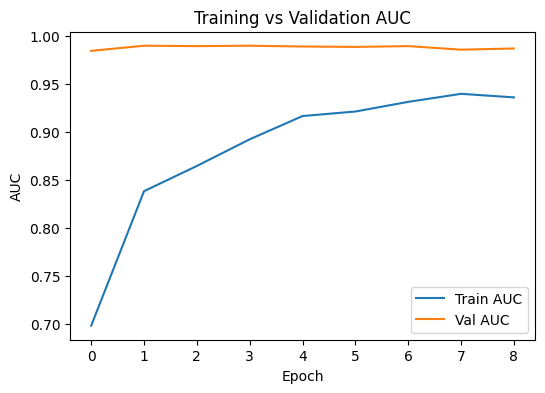

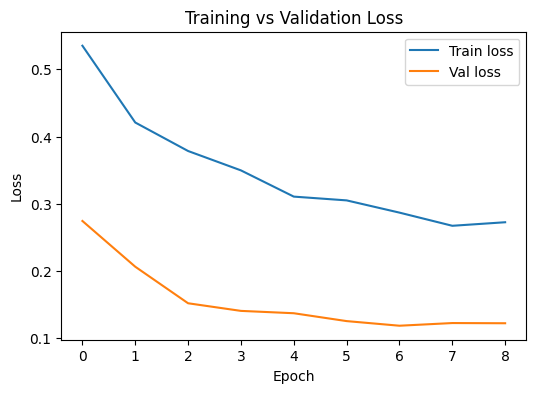

In [ ]:
# Plot training & validation AUC over epochs
plt.figure(figsize=(6,4))
plt.plot(history.history['AUC'], label='Train AUC')
plt.plot(history.history['val_AUC'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.title('Training vs Validation AUC')
plt.show()
# Plot training & validation loss over epochs
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [ ]:
# Evaluate on test set
test_loss, test_acc, test_auc = model.evaluate([X_test_img, X_test_quality],
y_test, verbose=0)
print(f"Test AUC: {test_auc:.3f}, Test accuracy: {test_acc:.3f}")
# Get predicted probabilities for test set
y_proba = model.predict([X_test_img, X_test_quality]).ravel()
# Compute ROC curve and AUC using scikit-learn for demonstration
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
print(f"Calculated Test AUC (sklearn): {auc_score:.3f}")

Test AUC: 0.975, Test accuracy: 0.971
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step
Calculated Test AUC (sklearn): 0.975


In [ ]:
# Classify predictions at threshold 0.5
y_pred_class = (y_proba >= 0.5).astype(int)
# Compute confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_class)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp+fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn+fp) > 0 else 0.0
print("Confusion Matrix (TN, FP, FN, TP):", tn, fp, fn, tp)
print(f"Sensitivity (Recall for glaucoma) = {sensitivity:.3f}")
print(f"Specificity (Recall for normal) = {specificity:.3f}")

Confusion Matrix (TN, FP, FN, TP): 17 2 0 50
Sensitivity (Recall for glaucoma) = 1.000
Specificity (Recall for normal) = 0.895


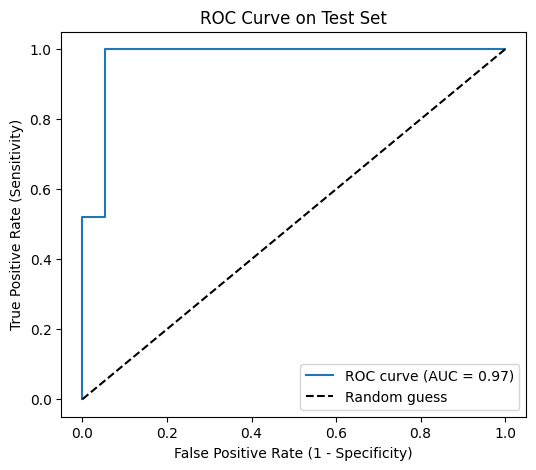

In [ ]:
# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1],[0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve on Test Set")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
from PIL import Image
import cv2

# Identify last convolution layer in ResNet50
last_conv_layer_name = "conv5_block3_out"

# Model to get conv output and final prediction
grad_model = models.Model(
    inputs=model.inputs,
    outputs=[model.get_layer(last_conv_layer_name).output, model.output]
)

def make_gradcam_heatmap(image, quality):
    """
    image: (224,224,3)
    quality: scalar (1,)
    """

    # Expand dims to create batch
    image = np.expand_dims(image, axis=0)
    quality = np.expand_dims(quality, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([image, quality], training=False)

        # probability of glaucoma class
        loss = predictions[:, 0]

    # gradients
    grads = tape.gradient(loss, conv_outputs)[0]
    conv_outputs = conv_outputs[0]

    # importance of each filter
    weights = tf.reduce_mean(grads, axis=(0, 1)).numpy()

    # weighted sum
    cam = np.zeros(conv_outputs.shape[:2], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * conv_outputs[:, :, i]

    # ReLU
    cam = np.maximum(cam, 0)

    # normalize heatmap
    heatmap = cam / (np.max(cam) + 1e-8)

    return heatmap


def overlay_heatmap_on_image(heatmap, original_image):
    """
    Overlay Grad-CAM heatmap on original image
    """

    # resize heatmap to image size
    heatmap_resized = Image.fromarray(
        (heatmap * 255).astype(np.uint8)
    ).resize(original_image.size, resample=Image.BILINEAR)

    heatmap_resized = np.array(heatmap_resized)

    # apply colormap
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # convert BGR -> RGB
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # overlay heatmap
    superimposed_img = (
        0.4 * heatmap_color + np.array(original_image).astype(np.float32)
    )

    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return Image.fromarray(superimposed_img)

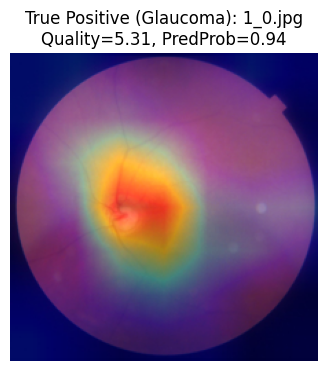

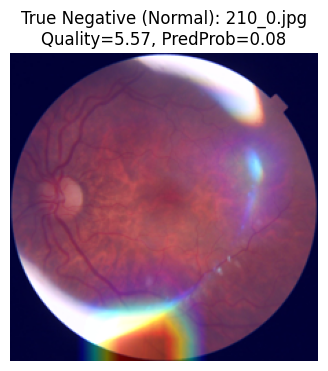

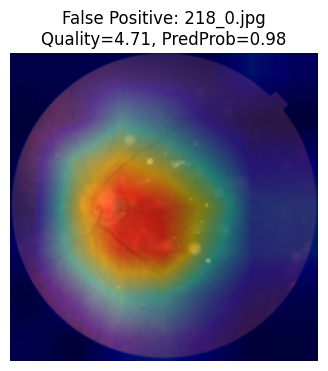

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

for desc, idx in examples.items():
    img_arr = X_test_img[idx]
    q_val = X_test_quality[idx]

    heatmap = make_gradcam_heatmap(img_arr, q_val)

    img_name = test_df.iloc[idx]["Image Name"]
    img_path = os.path.join(IMAGES_DIR, str(img_name))

    orig = Image.open(img_path).convert("RGB")
    orig = orig.resize((IMG_SIZE, IMG_SIZE))

    overlay = overlay_heatmap_on_image(heatmap, orig)

    plt.figure(figsize=(4,4))
    plt.imshow(overlay)
    plt.title(
        f"{desc}: {img_name}\n"
        f"Quality={test_df.iloc[idx]['Quality Score']}, PredProb={y_proba[idx]:.2f}"
    )
    plt.axis("off")
    plt.show()

In [ ]:
import os
import numpy as np

# Pastikan folder gambar benar (kalau gambarnya ada di root)
IMAGES_DIR = "."   # ganti ke "Images" kalau memang ada folder Images

# Simulate predictions on "new" images (pakai 2 contoh dari test_df)
new_images = [
    test_df.iloc[0],    # first test image
    test_df.iloc[-1]    # last test image
]

for row in new_images:
    img_name = row['Image Name']
    true_label = row['Label']
    quality_score = row['Quality Score']

    # Load and preprocess image
    img_pre = load_and_preprocess_image(os.path.join(IMAGES_DIR, str(img_name)))
    img_pre = np.expand_dims(img_pre, axis=0)

    # Normalize quality score to [0,1]
    quality_input = np.array([[float(quality_score) / 10.0]])

    # Predict probability
    pred_prob = model.predict([img_pre, quality_input], verbose=0)[0, 0]
    pred_label = "GON+" if pred_prob >= 0.5 else "GON-"

    print(
        f"Image {img_name}: True Label={true_label}, Predicted={pred_label}, "
        f"Confidence={pred_prob:.2%}, Quality={quality_score}"
    )

Image 1_0.jpg: True Label=GON+, Predicted=GON+, Confidence=94.17%, Quality=5.31
Image 282_1.jpg: True Label=GON-, Predicted=GON-, Confidence=30.54%, Quality=6.68


In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle
from PIL import Image

# ====== UBAH SESUAI FOLDER KAMU ======
LABELS_CSV = "/content/Labels.csv"
IMAGE_DIR   = "/content/Images"
OUT_DIR     = "/content/video_assets_hd"

os.makedirs(OUT_DIR, exist_ok=True)

# Load dataframe
df = pd.read_csv(LABELS_CSV)

# Rapikan nama kolom kalau ada spasi aneh
df.columns = [c.strip() for c in df.columns]

print("Columns:", df.columns.tolist())
print("Total rows:", len(df))
df.head()

Columns: ['Image Name', 'Patient', 'Label', 'Quality Score', 'Unnamed: 4']
Total rows: 747


,Image Name,Patient,Label,Quality Score,Unnamed: 4
0,0_0.jpg,0,GON+,6.18,NaN
1,1_0.jpg,1,GON+,5.31,NaN
2,1_1.jpg,1,GON+,4.37,NaN
3,2_0.jpg,2,GON+,3.51,NaN
4,2_1.jpg,2,GON+,4.24,NaN


In [ ]:
# Ukuran full HD
FIG_W, FIG_H, DPI = 16, 9, 120  # 16*120=1920, 9*120=1080

def save_fig(path, transparent=False):
    plt.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white", transparent=transparent)
    print(f"Saved to: {path}")

def infer_patient_id(name):
    """
    Coba infer patient ID dari nama file seperti '123_0.jpg' -> '123'
    Sesuaikan kalau format kamu berbeda.
    """
    base = os.path.splitext(str(name))[0]
    return base.split("_")[0]

# Kalau tidak ada Patient ID, buat dari Image Name
patient_col_candidates = [c for c in df.columns if c.lower() in ["patient id", "patient_id", "patient", "id"]]
if patient_col_candidates:
    PATIENT_COL = patient_col_candidates[0]
else:
    PATIENT_COL = "Patient_ID"
    df[PATIENT_COL] = df["Image Name"].apply(infer_patient_id)

print("Using patient column:", PATIENT_COL)

# Pastikan kolom penting ada
required = ["Image Name", "Quality Score", "Label", PATIENT_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Kolom ini belum ada di dataframe: {missing}")

Using patient column: Patient


Saved to: /content/video_assets_hd/01_dataset_overview_hd.png


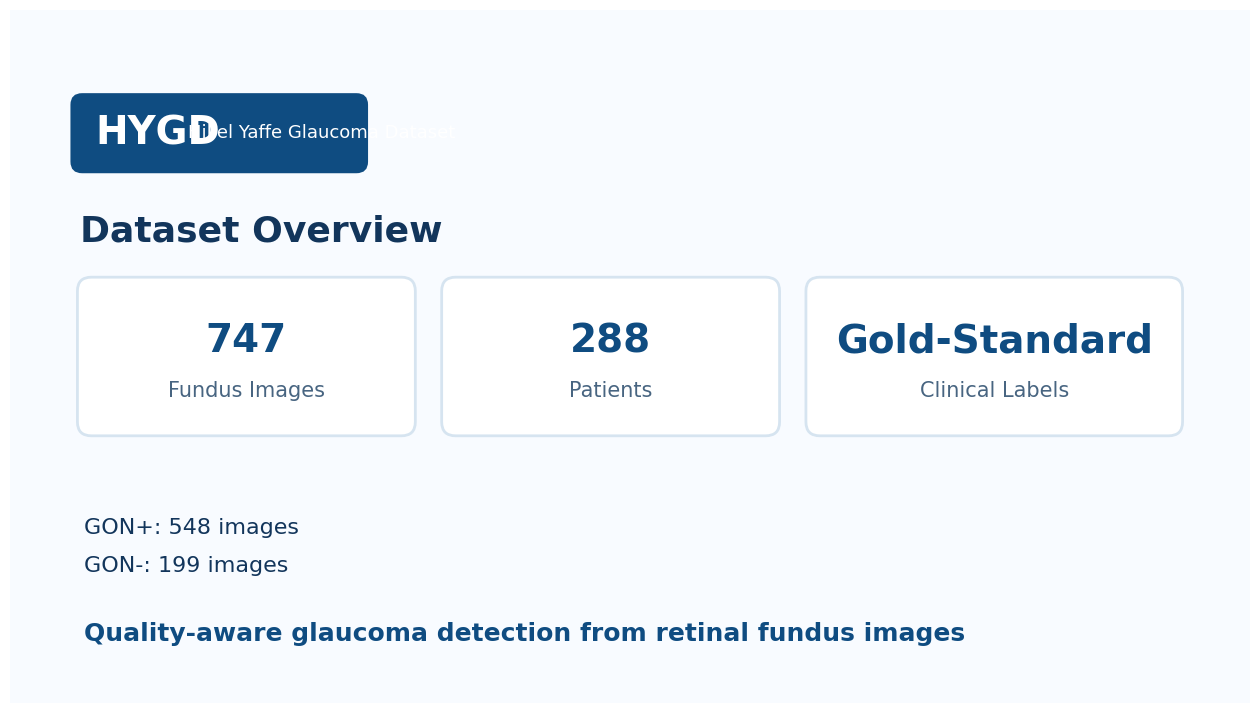

In [ ]:
# Hitung statistik utama
n_images = len(df)
n_patients = df[PATIENT_COL].nunique()
class_counts = df["Label"].value_counts()

gon_pos = int(class_counts.get("GON+", 0))
gon_neg = int(class_counts.get("GON-", 0))

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

# Background
ax.add_patch(Rectangle((0, 0), 16, 9, color="#F8FBFF"))

# HYGD badge / pseudo-logo
badge = FancyBboxPatch((0.8, 6.9), 3.8, 1.0,
                       boxstyle="round,pad=0.02,rounding_size=0.15",
                       facecolor="#0F4C81", edgecolor="none")
ax.add_patch(badge)
ax.text(1.1, 7.4, "HYGD", fontsize=28, color="white", weight="bold", va="center")
ax.text(2.3, 7.4, "Hillel Yaffe Glaucoma Dataset", fontsize=13, color="white", va="center")

# Title
ax.text(0.9, 6.0, "Dataset Overview", fontsize=26, weight="bold", color="#12355B")

# Cards
cards = [
    (0.9, 3.5, 4.3, 2.0, "747" if n_images == 747 else str(n_images), "Fundus Images"),
    (5.6, 3.5, 4.3, 2.0, "288" if n_patients == 288 else str(n_patients), "Patients"),
    (10.3, 3.5, 4.8, 2.0, "Gold-Standard", "Clinical Labels")
]

for x, y, w, h, big, small in cards:
    card = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.03,rounding_size=0.18",
                          facecolor="white", edgecolor="#D6E4F0", linewidth=2)
    ax.add_patch(card)
    ax.text(x + w/2, y + 1.2, big, fontsize=28, weight="bold", color="#0F4C81",
            ha="center", va="center")
    ax.text(x + w/2, y + 0.55, small, fontsize=15, color="#486581",
            ha="center", va="center")

# Class distribution text
ax.text(0.95, 2.2, f"GON+: {gon_pos} images", fontsize=16, color="#12355B")
ax.text(0.95, 1.7, f"GON-: {gon_neg} images", fontsize=16, color="#12355B")

ax.text(0.95, 0.8, "Quality-aware glaucoma detection from retinal fundus images",
        fontsize=18, color="#0F4C81", weight="bold")

save_fig(os.path.join(OUT_DIR, "01_dataset_overview_hd.png"))
plt.show()

Saved to: /content/video_assets_hd/02b_quality_comparison_captioned_hd.png


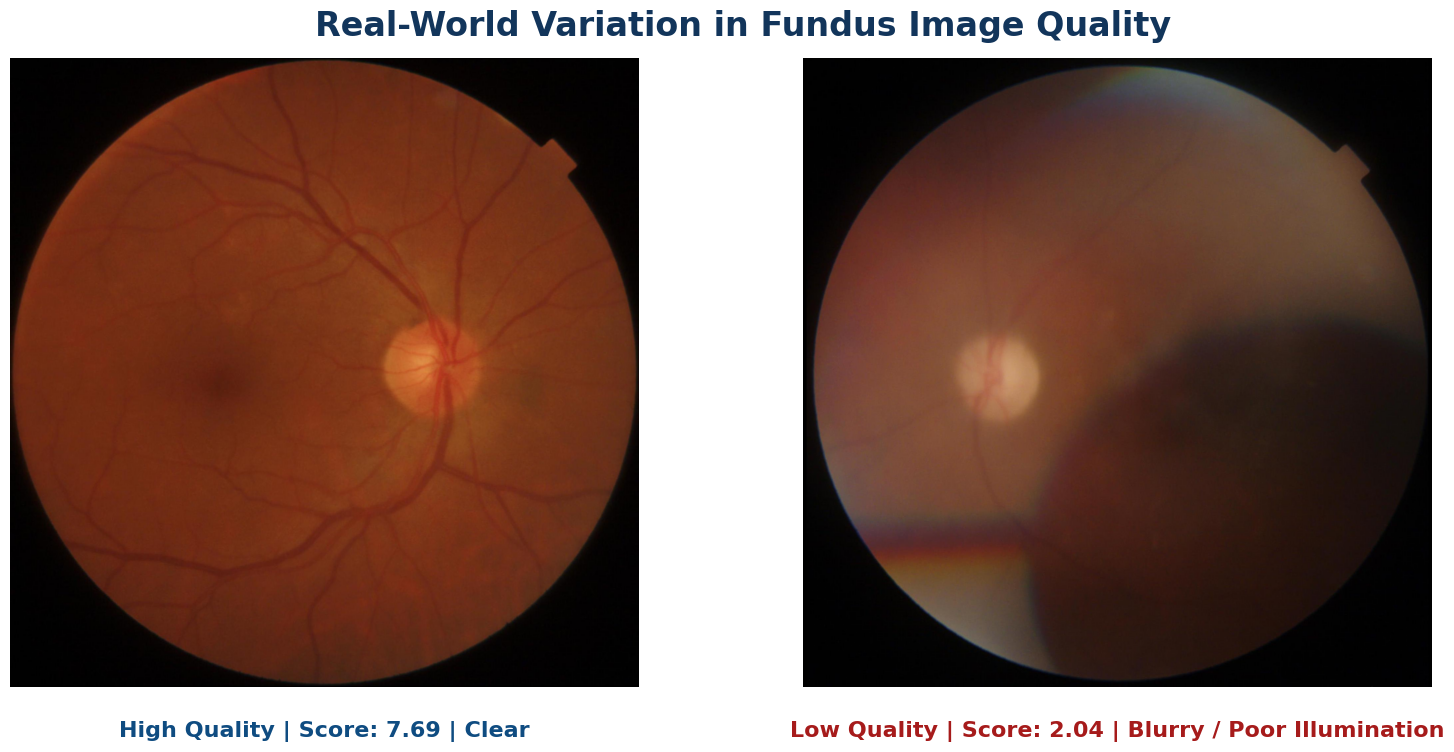

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

LABELS_CSV = "/content/Labels.csv"
OUT_DIR = "/content/video_assets_hd"
os.makedirs(OUT_DIR, exist_ok=True)

# otomatis cek folder gambar
if os.path.exists("/content/Images"):
    IMAGE_DIR = "/content/Images"
else:
    IMAGE_DIR = "/content"

df = pd.read_csv(LABELS_CSV)
df.columns = [c.strip() for c in df.columns]

FIG_W, FIG_H, DPI = 16, 9, 120

def save_fig(path, transparent=False):
    plt.savefig(path, dpi=DPI, bbox_inches="tight",
                facecolor="white", transparent=transparent)
    print(f"Saved to: {path}")

def load_img(img_name):
    path = os.path.join(IMAGE_DIR, str(img_name))
    if not os.path.exists(path):
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")
    return Image.open(path).convert("RGB")

high_row = df.sort_values("Quality Score", ascending=False).iloc[0]
low_row = df.sort_values("Quality Score", ascending=True).iloc[0]

high_img = load_img(high_row["Image Name"])
low_img = load_img(low_row["Image Name"])

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H/1.2))

axes[0].imshow(high_img)
axes[0].axis("off")
axes[0].text(0.5, -0.08,
             f"High Quality | Score: {high_row['Quality Score']:.2f} | Clear",
             transform=axes[0].transAxes, ha="center",
             fontsize=16, color="#0F4C81", weight="bold")

axes[1].imshow(low_img)
axes[1].axis("off")
axes[1].text(0.5, -0.08,
             f"Low Quality | Score: {low_row['Quality Score']:.2f} | Blurry / Poor Illumination",
             transform=axes[1].transAxes, ha="center",
             fontsize=16, color="#A61B1B", weight="bold")

fig.suptitle("Real-World Variation in Fundus Image Quality",
             fontsize=24, weight="bold", color="#12355B", y=0.98)

plt.tight_layout()
save_fig(os.path.join(OUT_DIR, "02b_quality_comparison_captioned_hd.png"))
plt.show()

Saved to: /content/video_assets_hd/03_quality_histogram_hd.png


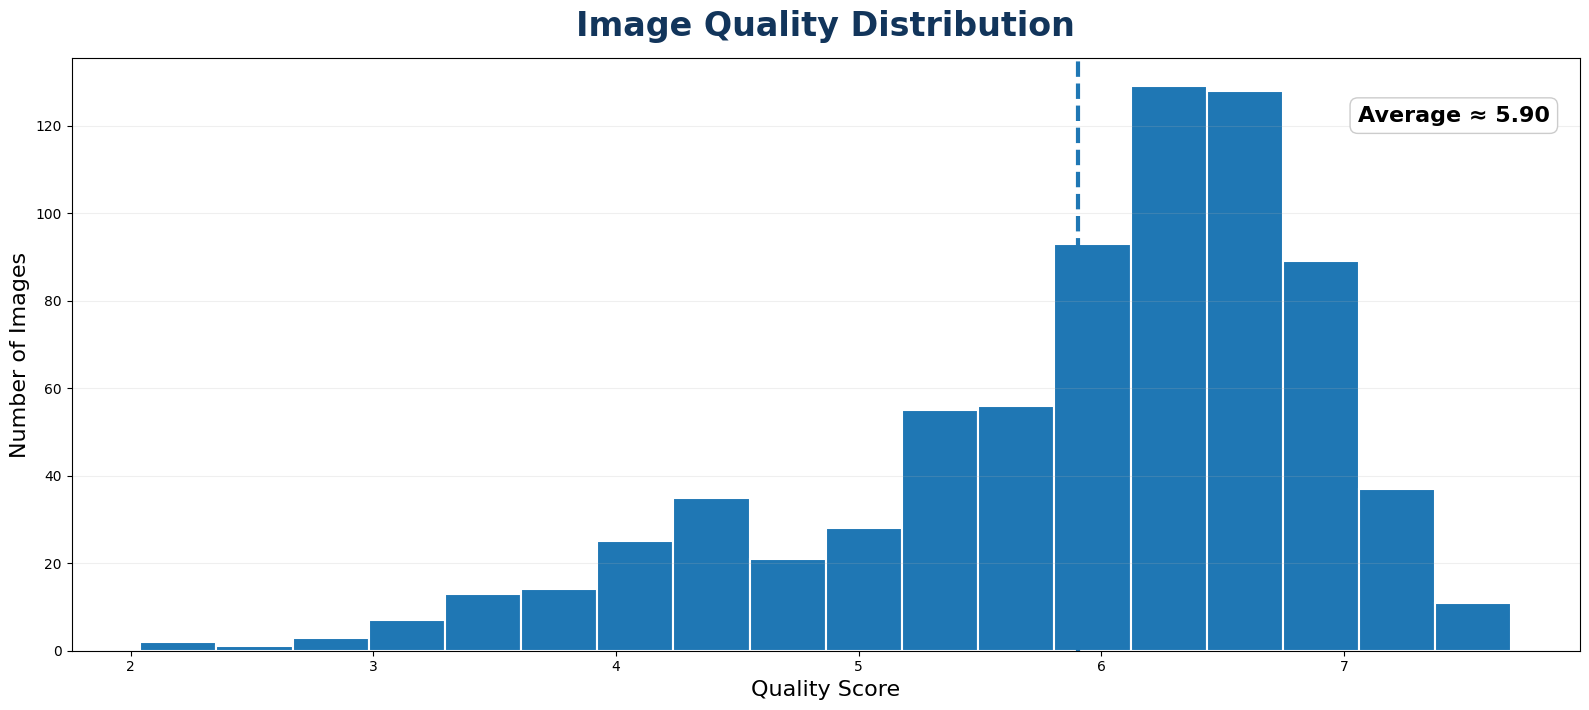

In [ ]:
quality_mean = df["Quality Score"].mean()

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H/1.25))
ax.hist(df["Quality Score"], bins=18, edgecolor="white", linewidth=1.5)
ax.axvline(quality_mean, linestyle="--", linewidth=3)

ax.set_title("Image Quality Distribution", fontsize=24, weight="bold", color="#12355B", pad=16)
ax.set_xlabel("Quality Score", fontsize=16)
ax.set_ylabel("Number of Images", fontsize=16)

ax.text(
    0.98, 0.92,
    f"Average ≈ {quality_mean:.2f}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=16, weight="bold",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#CCCCCC")
)

ax.grid(axis="y", alpha=0.2)
plt.tight_layout()

save_fig(os.path.join(OUT_DIR, "03_quality_histogram_hd.png"))
plt.show()